# Bengaluru Water Consumption Forecasting — Clean Feature Engineering & Modeling

This notebook is a cleaned version of the original feature-engineering notebook. It uses `location_id` as the time-series key, creates leakage-safe historical features, removes structurally incomplete rows only for model training, and evaluates models using a chronological split.

In [1]:
import pandas as pd
import numpy as np

file_path = "../data/processed/bengaluru_water_consumption_cleaned.csv"

df = pd.read_csv(file_path)
df["month"] = pd.to_datetime(df["month"])

# One time series per location, not per ward_number.
df = df.sort_values(["location_id", "month"]).reset_index(drop=True)

print("Shape:", df.shape)
display(df.head())


Shape: (2424, 6)


,month,ward_number,ward_name,connections,consumption_ml,location_id
0,2025-04-01,100,Basaveshwaranagar,5760,177.260000,100_basaveshwaranagar
1,2025-05-01,100,Basaveshwaranagar,5761,170.032536,100_basaveshwaranagar
2,2025-06-01,100,Basaveshwaranagar,5763,172.070536,100_basaveshwaranagar
3,2025-07-01,100,Basaveshwaranagar,5764,166.510000,100_basaveshwaranagar
4,2025-08-01,100,Basaveshwaranagar,5767,166.100000,100_basaveshwaranagar


## 1. Basic feature: consumption per connection

In [2]:
df["consumption_per_connection"] = np.where(
    df["connections"] != 0,
    df["consumption_ml"] / df["connections"],
    np.nan
)

print("Missing:", df["consumption_per_connection"].isna().sum())
print("Infinite:", np.isinf(df["consumption_per_connection"]).sum())
display(df[["month", "location_id", "connections", "consumption_ml", "consumption_per_connection"]].head(10))


Missing: 0
Infinite: 0


,month,location_id,connections,consumption_ml,consumption_per_connection
0,2025-04-01,100_basaveshwaranagar,5760,177.260000,0.030774
1,2025-05-01,100_basaveshwaranagar,5761,170.032536,0.029514
2,2025-06-01,100_basaveshwaranagar,5763,172.070536,0.029858
3,2025-07-01,100_basaveshwaranagar,5764,166.510000,0.028888
4,2025-08-01,100_basaveshwaranagar,5767,166.100000,0.028802
5,2025-09-01,100_basaveshwaranagar,5771,167.030000,0.028943
6,2025-10-01,100_basaveshwaranagar,5772,169.710000,0.029402
7,2025-11-01,100_basaveshwaranagar,5771,168.340000,0.029170
8,2025-12-01,100_basaveshwaranagar,5771,157.760000,0.027337
9,2026-01-01,100_basaveshwaranagar,5774,170.220000,0.029480


## 2. Previous-month features and consumption change

In [3]:
df["previous_consumption_ml"] = (
    df.groupby("location_id")["consumption_ml"].shift(1)
)

df["previous_consumption_per_connection"] = (
    df.groupby("location_id")["consumption_per_connection"].shift(1)
)

df["consumption_change_ml"] = (
    df["consumption_ml"] - df["previous_consumption_ml"]
)

# First month has no previous month -> NaN.
# If the previous month is exactly zero, define the percentage change as 0
# for the zero-to-zero case rather than creating 0/0.
df["consumption_change_pct"] = np.where(
    df["previous_consumption_ml"].isna(),
    np.nan,
    np.where(
        df["previous_consumption_ml"] == 0,
        0,
        (df["consumption_change_ml"] / df["previous_consumption_ml"]) * 100
    )
)

display(df[[
    "month", "location_id", "consumption_ml",
    "previous_consumption_ml", "consumption_change_ml",
    "consumption_change_pct"
]].head(15))


,month,location_id,consumption_ml,previous_consumption_ml,consumption_change_ml,consumption_change_pct
0,2025-04-01,100_basaveshwaranagar,177.260000,NaN,NaN,NaN
1,2025-05-01,100_basaveshwaranagar,170.032536,177.260000,-7.227464,-4.077324
2,2025-06-01,100_basaveshwaranagar,172.070536,170.032536,2.038000,1.198594
3,2025-07-01,100_basaveshwaranagar,166.510000,172.070536,-5.560536,-3.231545
4,2025-08-01,100_basaveshwaranagar,166.100000,166.510000,-0.410000,-0.246231
5,2025-09-01,100_basaveshwaranagar,167.030000,166.100000,0.930000,0.559904
6,2025-10-01,100_basaveshwaranagar,169.710000,167.030000,2.680000,1.604502
7,2025-11-01,100_basaveshwaranagar,168.340000,169.710000,-1.370000,-0.807259
8,2025-12-01,100_basaveshwaranagar,157.760000,168.340000,-10.580000,-6.284900
9,2026-01-01,100_basaveshwaranagar,170.220000,157.760000,12.460000,7.898073


## 3. Leakage-safe rolling features

The rolling features use `shift(1)` so the current month is not included in its own historical summary. When the model uses the current month to predict the next month, this prevents the rolling feature from accidentally incorporating the value being forecast from the same time point.

In [4]:
# Historical 3-month average: only months before the current row.
df["rolling_3_month_avg"] = (
    df.groupby("location_id")["consumption_ml"]
      .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)

df["deviation_from_rolling_avg"] = (
    df["consumption_ml"] - df["rolling_3_month_avg"]
)

df["deviation_pct"] = np.where(
    df["rolling_3_month_avg"].isna(),
    np.nan,
    np.where(
        df["rolling_3_month_avg"] == 0,
        0,
        (df["deviation_from_rolling_avg"] / df["rolling_3_month_avg"]) * 100
    )
)

# Historical 3-month standard deviation. At least two historical observations
# are required for a meaningful sample standard deviation.
df["rolling_3_month_std"] = (
    df.groupby("location_id")["consumption_ml"]
      .transform(lambda x: x.shift(1).rolling(window=3, min_periods=2).std())
)

display(df[[
    "month", "location_id", "consumption_ml",
    "rolling_3_month_avg", "deviation_from_rolling_avg",
    "deviation_pct", "rolling_3_month_std"
]].head(15))


,month,location_id,consumption_ml,rolling_3_month_avg,deviation_from_rolling_avg,deviation_pct,rolling_3_month_std
0,2025-04-01,100_basaveshwaranagar,177.260000,NaN,NaN,NaN,NaN
1,2025-05-01,100_basaveshwaranagar,170.032536,177.260000,-7.227464,-4.077324,NaN
2,2025-06-01,100_basaveshwaranagar,172.070536,173.646268,-1.575732,-0.907438,5.110589
3,2025-07-01,100_basaveshwaranagar,166.510000,173.121024,-6.611024,-3.818730,3.726487
4,2025-08-01,100_basaveshwaranagar,166.100000,169.537691,-3.437691,-2.027685,2.813102
5,2025-09-01,100_basaveshwaranagar,167.030000,168.226845,-1.196845,-0.711447,3.335040
6,2025-10-01,100_basaveshwaranagar,169.710000,166.546667,3.163333,1.899368,0.466083
7,2025-11-01,100_basaveshwaranagar,168.340000,167.613333,0.726667,0.433538,1.874362
8,2025-12-01,100_basaveshwaranagar,157.760000,168.360000,-10.600000,-6.296032,1.340112
9,2026-01-01,100_basaveshwaranagar,170.220000,165.270000,4.950000,2.995099,6.539824


## 4. Lag features

In [5]:
df["consumption_lag_2"] = (
    df.groupby("location_id")["consumption_ml"].shift(2)
)

df["consumption_lag_3"] = (
    df.groupby("location_id")["consumption_ml"].shift(3)
)

display(df[[
    "month", "location_id", "consumption_ml",
    "previous_consumption_ml", "consumption_lag_2", "consumption_lag_3"
]].head(15))


,month,location_id,consumption_ml,previous_consumption_ml,consumption_lag_2,consumption_lag_3
0,2025-04-01,100_basaveshwaranagar,177.260000,NaN,NaN,NaN
1,2025-05-01,100_basaveshwaranagar,170.032536,177.260000,NaN,NaN
2,2025-06-01,100_basaveshwaranagar,172.070536,170.032536,177.260000,NaN
3,2025-07-01,100_basaveshwaranagar,166.510000,172.070536,170.032536,177.260000
4,2025-08-01,100_basaveshwaranagar,166.100000,166.510000,172.070536,170.032536
5,2025-09-01,100_basaveshwaranagar,167.030000,166.100000,166.510000,172.070536
6,2025-10-01,100_basaveshwaranagar,169.710000,167.030000,166.100000,166.510000
7,2025-11-01,100_basaveshwaranagar,168.340000,169.710000,167.030000,166.100000
8,2025-12-01,100_basaveshwaranagar,157.760000,168.340000,169.710000,167.030000
9,2026-01-01,100_basaveshwaranagar,170.220000,157.760000,168.340000,169.710000


## 5. Next-month forecasting target

In [6]:
df["target_next_month_consumption"] = (
    df.groupby("location_id")["consumption_ml"].shift(-1)
)

display(df[[
    "month", "location_id", "consumption_ml",
    "target_next_month_consumption"
]].head(15))


,month,location_id,consumption_ml,target_next_month_consumption
0,2025-04-01,100_basaveshwaranagar,177.260000,170.032536
1,2025-05-01,100_basaveshwaranagar,170.032536,172.070536
2,2025-06-01,100_basaveshwaranagar,172.070536,166.510000
3,2025-07-01,100_basaveshwaranagar,166.510000,166.100000
4,2025-08-01,100_basaveshwaranagar,166.100000,167.030000
5,2025-09-01,100_basaveshwaranagar,167.030000,169.710000
6,2025-10-01,100_basaveshwaranagar,169.710000,168.340000
7,2025-11-01,100_basaveshwaranagar,168.340000,157.760000
8,2025-12-01,100_basaveshwaranagar,157.760000,170.220000
9,2026-01-01,100_basaveshwaranagar,170.220000,166.000000


## 6. Final data-quality checks

In [7]:
print("Rows:", len(df))
print("Unique locations:", df["location_id"].nunique())
print("Unique months:", df["month"].nunique())

print("\nDuplicate location-month records:", df.duplicated(subset=["location_id", "month"]).sum())

print("\nMissing raw consumption:", df["consumption_ml"].isna().sum())

print("\nMissing values in engineered columns:")
missing = df.isna().sum()
print(missing[missing > 0])


Rows: 2424
Unique locations: 202
Unique months: 12

Duplicate location-month records: 0

Missing raw consumption: 0

Missing values in engineered columns:
previous_consumption_ml                202
previous_consumption_per_connection    202
consumption_change_ml                  202
consumption_change_pct                 202
rolling_3_month_avg                    202
deviation_from_rolling_avg             202
deviation_pct                          202
rolling_3_month_std                    404
consumption_lag_2                      404
consumption_lag_3                      606
target_next_month_consumption          202
dtype: int64


## 7. Create the ML dataset

The missing values here are structural: early months do not have enough history for all lag/rolling features, and the final month has no next-month target. We do not median-impute these rows; instead, we train only on rows where all selected features and the target are available.

In [8]:
features = [
    "connections",
    "consumption_ml",
    "consumption_per_connection",
    "previous_consumption_ml",
    "previous_consumption_per_connection",
    "consumption_change_ml",
    "consumption_change_pct",
    "rolling_3_month_avg",
    "deviation_from_rolling_avg",
    "deviation_pct",
    "rolling_3_month_std",
    "consumption_lag_2",
    "consumption_lag_3"
]

target = "target_next_month_consumption"

model_df = df[["month", "location_id"] + features + [target]].dropna().copy()

print("Original rows:", len(df))
print("Model rows:", len(model_df))
print("Rows removed:", len(df) - len(model_df))
print("\nMissing values in model_df:")
print(model_df.isna().sum()[model_df.isna().sum() > 0])


Original rows: 2424
Model rows: 1616
Rows removed: 808

Missing values in model_df:
Series([], dtype: int64)


## 8. Chronological train / validation / test split

In [9]:
print(model_df.groupby("month")["location_id"].count())

# With the current 12-month history, use earlier months for training,
# January 2026 for validation, and February 2026 for final testing.
train_df = model_df[model_df["month"] <= "2025-12-01"].copy()
validation_df = model_df[model_df["month"] == "2026-01-01"].copy()
test_df = model_df[model_df["month"] == "2026-02-01"].copy()

print("Training:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)


month
2025-07-01    202
2025-08-01    202
2025-09-01    202
2025-10-01    202
2025-11-01    202
2025-12-01    202
2026-01-01    202
2026-02-01    202
Name: location_id, dtype: int64
Training: (1212, 16)
Validation: (202, 16)
Test: (202, 16)


## 9. Prepare model matrices

No `SimpleImputer` is needed because `model_df` has already removed rows with structurally unavailable features.

In [10]:
X_train = train_df[features].copy()
y_train = train_df[target].copy()

X_val = validation_df[features].copy()
y_val = validation_df[target].copy()

X_test = test_df[features].copy()
y_test = test_df[target].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nMissing values:")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_val.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())


X_train: (1212, 13)
y_train: (1212,)
X_val: (202, 13)
y_val: (202,)
X_test: (202, 13)
y_test: (202,)

Missing values:
Train: 0
Validation: 0
Test: 0


# Model 1 — Random Forest Regression

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_val_pred_rf = rf_model.predict(X_val)

rf_mae_val = mean_absolute_error(y_val, y_val_pred_rf)
rf_rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
rf_r2_val = r2_score(y_val, y_val_pred_rf)

print("Random Forest Validation Results")
print("MAE :", rf_mae_val)
print("RMSE:", rf_rmse_val)
print("R²  :", rf_r2_val)


Random Forest Validation Results
MAE : 4.799722452135483
RMSE: 7.006770178815431
R²  : 0.9937695061650915


In [12]:
import joblib

joblib.dump(
    rf_model,
    "../models/random_forest_model.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


# Model 2 — Gradient Boosting

In [13]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

gb_model.fit(X_train, y_train)
y_val_pred_gb = gb_model.predict(X_val)

gb_mae_val = mean_absolute_error(y_val, y_val_pred_gb)
gb_rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred_gb))
gb_r2_val = r2_score(y_val, y_val_pred_gb)

print("Gradient Boosting Validation Results")
print("MAE :", gb_mae_val)
print("RMSE:", gb_rmse_val)
print("R²  :", gb_r2_val)


Gradient Boosting Validation Results
MAE : 5.645381414582795
RMSE: 8.905682138277554
R²  : 0.9899348302145933


# Validation comparison with a naive baseline

In [14]:
# Naive forecast: next month ≈ current month.
baseline_val_pred = validation_df["consumption_ml"].values

baseline_mae = mean_absolute_error(y_val, baseline_val_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_val_pred))
baseline_r2 = r2_score(y_val, baseline_val_pred)

comparison = pd.DataFrame({
    "Model": ["Naive Baseline", "Random Forest", "Gradient Boosting"],
    "MAE": [baseline_mae, rf_mae_val, gb_mae_val],
    "RMSE": [baseline_rmse, rf_rmse_val, gb_rmse_val],
    "R2": [baseline_r2, rf_r2_val, gb_r2_val]
})

display(comparison.sort_values("MAE"))

# Select the best ML model by validation MAE.
best_model_name = "Random Forest" if rf_mae_val <= gb_mae_val else "Gradient Boosting"
best_model = rf_model if best_model_name == "Random Forest" else gb_model

print("Selected model:", best_model_name)


,Model,MAE,RMSE,R2
0,Naive Baseline,3.707129,5.548991,0.996092
1,Random Forest,4.799722,7.006770,0.993770
2,Gradient Boosting,5.645381,8.905682,0.989935


Selected model: Random Forest


# Final test evaluation

In [15]:
y_test_pred_rf = rf_model.predict(X_test)
y_test_pred_gb = gb_model.predict(X_test)

baseline_test_pred = test_df["consumption_ml"].values

results_test = pd.DataFrame({
    "Model": ["Naive Baseline", "Random Forest", "Gradient Boosting"],
    "MAE": [
        mean_absolute_error(y_test, baseline_test_pred),
        mean_absolute_error(y_test, y_test_pred_rf),
        mean_absolute_error(y_test, y_test_pred_gb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, baseline_test_pred)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_test_pred_gb))
    ],
    "R2": [
        r2_score(y_test, baseline_test_pred),
        r2_score(y_test, y_test_pred_rf),
        r2_score(y_test, y_test_pred_gb)
    ]
})

display(results_test.sort_values("MAE"))


,Model,MAE,RMSE,R2
1,Random Forest,6.274010,8.518070,0.989927
2,Gradient Boosting,7.133246,10.637717,0.984291
0,Naive Baseline,7.135396,9.556972,0.987320


# Final predictions for Power BI / anomaly analysis

In [16]:
if best_model_name == "Random Forest":
    best_test_pred = y_test_pred_rf
else:
    best_test_pred = y_test_pred_gb

final_predictions = test_df[
    ["location_id", "connections"]
].copy()

# The model uses February 2026 information
# to predict March 2026 consumption.
final_predictions["forecast_month"] = (
    test_df["month"] + pd.DateOffset(months=1)
)

# Actual March 2026 consumption
final_predictions["actual_consumption_ml"] = y_test.values

# Predicted March 2026 consumption
final_predictions["predicted_consumption_ml"] = best_test_pred

# Prediction error = predicted - actual
final_predictions["prediction_error_ml"] = (
    final_predictions["predicted_consumption_ml"]
    - final_predictions["actual_consumption_ml"]
)

final_predictions["absolute_error_ml"] = (
    final_predictions["prediction_error_ml"].abs()
)

# Percentage error
final_predictions["prediction_error_pct"] = np.where(
    final_predictions["actual_consumption_ml"] != 0,
    (
        final_predictions["prediction_error_ml"]
        / final_predictions["actual_consumption_ml"]
    ) * 100,
    np.nan
)

# Historical/anomaly features available at forecast time
anomaly_features = [
    "rolling_3_month_avg",
    "deviation_from_rolling_avg",
    "deviation_pct",
    "rolling_3_month_std",
    "consumption_change_pct",
    "consumption_lag_2",
    "consumption_lag_3"
]

for col in anomaly_features:
    final_predictions[col] = test_df[col].values

print("Final prediction rows:", len(final_predictions))
display(final_predictions.head(20))

Final prediction rows: 202


,location_id,connections,forecast_month,actual_consumption_ml,predicted_consumption_ml,prediction_error_ml,absolute_error_ml,prediction_error_pct,rolling_3_month_avg,deviation_from_rolling_avg,deviation_pct,rolling_3_month_std,consumption_change_pct,consumption_lag_2,consumption_lag_3
10,100_basaveshwaranagar,5775,2026-03-01,158.23,164.386321,6.156321,6.156321,3.890742,165.440000,0.560000,0.338491,6.717172,-2.479145,157.76,168.34
22,101_kamakshipalya,3686,2026-03-01,91.11,95.479592,4.369592,4.369592,4.795952,92.363333,4.046667,4.381248,4.019220,-0.186355,88.59,91.91
34,102_vrushabhavathi_nagar,4185,2026-03-01,96.20,97.159453,0.959453,0.959453,0.997352,95.066667,5.743333,6.041374,4.204549,0.890713,92.75,92.53
46,103_kaveripura,5040,2026-03-01,101.06,103.729504,2.669504,2.669504,2.641504,98.716667,7.843333,7.945298,7.131580,0.756430,91.50,98.89
58,104_govindrajnagara,2920,2026-03-01,75.32,73.703623,-1.616377,1.616377,-2.146013,68.576667,7.183333,10.474894,5.356252,1.405434,64.82,66.20
70,105_agrahara_dasarahalli,3218,2026-03-01,92.20,95.390285,3.190285,3.190285,3.460179,93.710000,3.920000,4.183118,3.513389,1.761518,89.66,95.53
82,106_dr._rajkumar_ward,2471,2026-03-01,76.88,79.161359,2.281359,2.281359,2.967429,80.160000,-0.210000,-0.261976,1.893436,-0.584432,78.15,81.91
94,107_shivanagar,2457,2026-03-01,85.37,86.653581,1.283581,1.283581,1.503550,87.133333,4.426667,5.080337,3.121431,6.713287,84.90,90.70
106,108_srirammandira_ward,4679,2026-03-01,112.16,116.994268,4.834268,4.834268,4.310154,118.616667,0.763333,0.643530,1.914480,-0.582945,116.45,119.32
118,109_chikpet,5623,2026-03-01,107.59,112.156484,4.566484,4.566484,4.244338,112.020000,-1.180000,-1.053383,1.951230,-2.933707,111.46,110.41


# Prediction Error Analysis


In [17]:
test_results = final_predictions[
    [
        "location_id",
        "forecast_month",
        "actual_consumption_ml",
        "predicted_consumption_ml",
        "prediction_error_ml",
        "absolute_error_ml",
        "prediction_error_pct"
    ]
].copy()

test_results = test_results.sort_values(
    "absolute_error_ml",
    ascending=False
)

print("Top 20 predictions with highest absolute error:")
display(test_results.head(20))

Top 20 predictions with highest absolute error:


,location_id,forecast_month,actual_consumption_ml,predicted_consumption_ml,prediction_error_ml,absolute_error_ml,prediction_error_pct
802,159_kengeri,2026-03-01,289.48,318.223348,28.743348,28.743348,9.929304
1426,25_horamavu,2026-03-01,165.27,136.739839,-28.530161,28.530161,-17.262758
1306,196_anjanapura,2026-03-01,398.77,371.098001,-27.671999,27.671999,-6.939338
1450,27_banasawadi,2026-03-01,260.34,285.844231,25.504231,25.504231,9.796509
1018,175_bommanahalli,2026-03-01,262.12,285.368719,23.248719,23.248719,8.869495
2218,85_doddanekkundi,2026-03-01,313.53,335.078022,21.548022,21.548022,6.872715
2242,86_marathalli,2026-03-01,156.37,177.273696,20.903696,20.903696,13.368099
2350,94_gandhinagar,2026-03-01,350.94,369.969185,19.029185,19.029185,5.422347
1762,50_benniganahalli,2026-03-01,361.26,379.568000,18.308000,18.308000,5.067818
2230,85_varthur,2026-03-01,102.27,84.161824,-18.108176,18.108176,-17.706245


# Location-level Error Analysis


In [18]:
location_error = (
    test_results
    .groupby(
        "location_id",
        as_index=False
    )
    .agg(
        actual_consumption_ml=("actual_consumption_ml", "mean"),
        predicted_consumption_ml=("predicted_consumption_ml", "mean"),
        mae_ml=("absolute_error_ml", "mean"),
        mean_error_pct=("prediction_error_pct", "mean")
    )
    .sort_values(
        "mae_ml",
        ascending=False
    )
)

print("Locations with highest prediction error:")
display(location_error.head(20))

Locations with highest prediction error:


,location_id,actual_consumption_ml,predicted_consumption_ml,mae_ml,mean_error_pct
66,159_kengeri,289.48,318.223348,28.743348,9.929304
118,25_horamavu,165.27,136.739839,28.530161,-17.262758
108,196_anjanapura,398.77,371.098001,27.671999,-6.939338
120,27_banasawadi,260.34,285.844231,25.504231,9.796509
84,175_bommanahalli,262.12,285.368719,23.248719,8.869495
184,85_doddanekkundi,313.53,335.078022,21.548022,6.872715
186,86_marathalli,156.37,177.273696,20.903696,13.368099
195,94_gandhinagar,350.94,369.969185,19.029185,5.422347
146,50_benniganahalli,361.26,379.568000,18.308000,5.067818
185,85_varthur,102.27,84.161824,18.108176,-17.706245


# Final risk-feature check

In [19]:
risk_variables = [
    "prediction_error_pct",
    "deviation_pct",
    "rolling_3_month_std",
    "consumption_change_pct"
]

display(final_predictions[risk_variables].describe())

print("Missing values in risk variables:")
print(final_predictions[risk_variables].isna().sum())

,prediction_error_pct,deviation_pct,rolling_3_month_std,consumption_change_pct
count,201.000000,202.000000,202.000000,202.000000
mean,2.790107,2.239998,4.676909,0.040056
std,5.183397,4.573438,5.267414,4.129398
min,-17.706245,-11.963050,0.000000,-10.719424
25%,0.891949,-0.256048,1.756301,-2.138379
50%,3.108897,1.526523,3.519519,-0.330437
75%,5.186468,3.880717,6.085763,1.725273
max,32.164511,29.433709,49.939255,37.533405


Missing values in risk variables:
prediction_error_pct      1
deviation_pct             0
rolling_3_month_std       0
consumption_change_pct    0
dtype: int64


# Actual vs Predicted Consumption


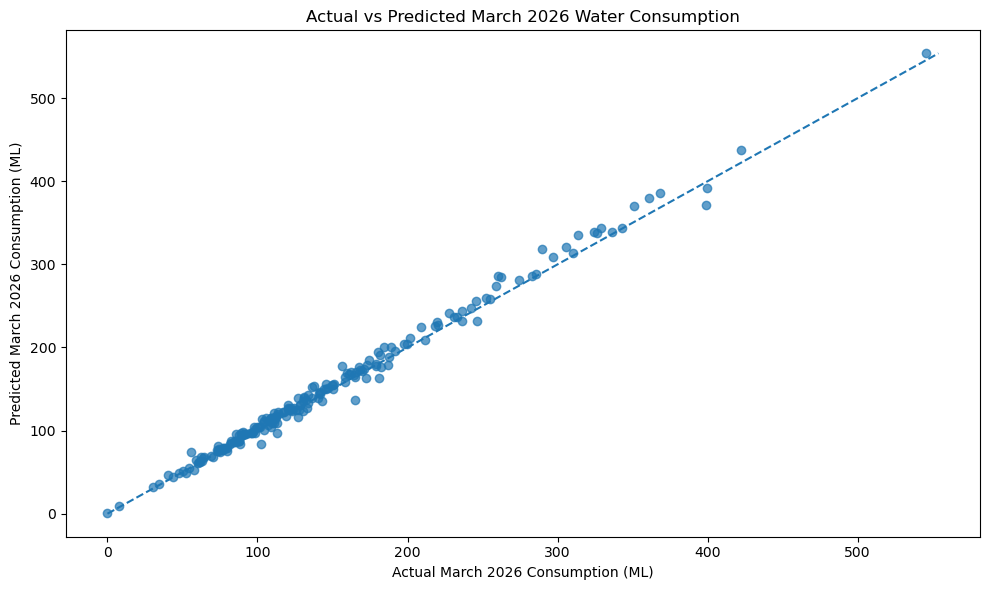

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.scatter(
    final_predictions["actual_consumption_ml"],
    final_predictions["predicted_consumption_ml"],
    alpha=0.7
)

min_value = min(
    final_predictions["actual_consumption_ml"].min(),
    final_predictions["predicted_consumption_ml"].min()
)

max_value = max(
    final_predictions["actual_consumption_ml"].max(),
    final_predictions["predicted_consumption_ml"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual March 2026 Consumption (ML)")
plt.ylabel("Predicted March 2026 Consumption (ML)")
plt.title("Actual vs Predicted March 2026 Water Consumption")

plt.tight_layout()
plt.show()

# Prediction Error Distribution


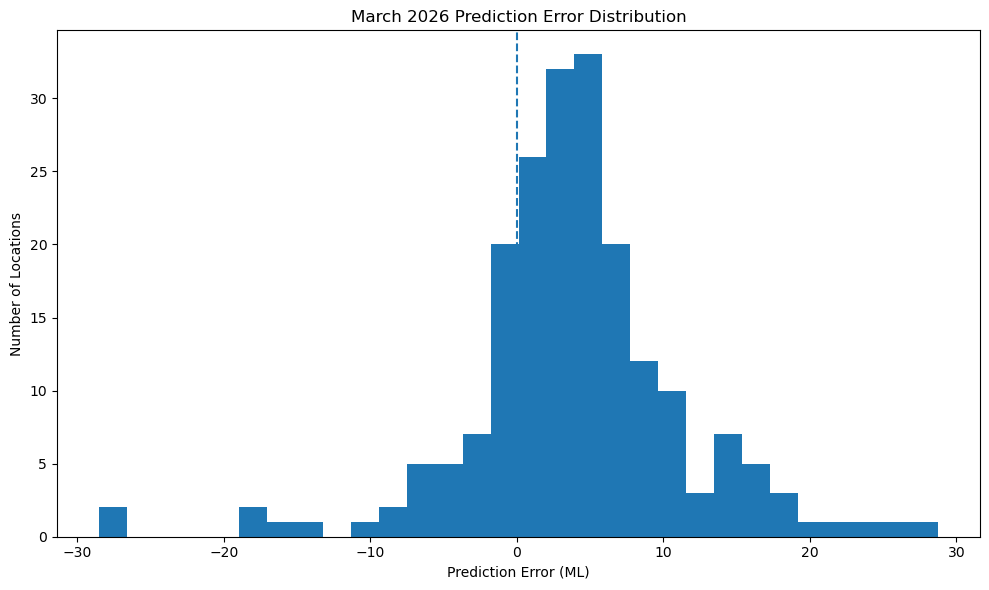

In [21]:
plt.figure(figsize=(10, 6))

plt.hist(
    final_predictions["prediction_error_ml"].dropna(),
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Prediction Error (ML)")
plt.ylabel("Number of Locations")
plt.title("March 2026 Prediction Error Distribution")

plt.tight_layout()
plt.show()

In [22]:
largest_errors = (
    test_results[
        [
            "location_id",
            "forecast_month",
            "actual_consumption_ml",
            "predicted_consumption_ml",
            "prediction_error_ml",
            "absolute_error_ml",
            "prediction_error_pct"
        ]
    ]
    .sort_values(
        "absolute_error_ml",
        ascending=False
    )
)

print("Top 20 largest prediction errors:")
display(largest_errors.head(20))

Top 20 largest prediction errors:


,location_id,forecast_month,actual_consumption_ml,predicted_consumption_ml,prediction_error_ml,absolute_error_ml,prediction_error_pct
802,159_kengeri,2026-03-01,289.48,318.223348,28.743348,28.743348,9.929304
1426,25_horamavu,2026-03-01,165.27,136.739839,-28.530161,28.530161,-17.262758
1306,196_anjanapura,2026-03-01,398.77,371.098001,-27.671999,27.671999,-6.939338
1450,27_banasawadi,2026-03-01,260.34,285.844231,25.504231,25.504231,9.796509
1018,175_bommanahalli,2026-03-01,262.12,285.368719,23.248719,23.248719,8.869495
2218,85_doddanekkundi,2026-03-01,313.53,335.078022,21.548022,21.548022,6.872715
2242,86_marathalli,2026-03-01,156.37,177.273696,20.903696,20.903696,13.368099
2350,94_gandhinagar,2026-03-01,350.94,369.969185,19.029185,19.029185,5.422347
1762,50_benniganahalli,2026-03-01,361.26,379.568000,18.308000,18.308000,5.067818
2230,85_varthur,2026-03-01,102.27,84.161824,-18.108176,18.108176,-17.706245


# Prediction Error Summary


In [23]:
print(
    "Mean error (ML):",
    final_predictions["prediction_error_ml"].mean()
)

print(
    "Median error (ML):",
    final_predictions["prediction_error_ml"].median()
)

print(
    "Maximum absolute error (ML):",
    final_predictions["absolute_error_ml"].max()
)

print(
    "Minimum error (ML):",
    final_predictions["prediction_error_ml"].min()
)

print(
    "Maximum error (ML):",
    final_predictions["prediction_error_ml"].max()
)

Mean error (ML): 3.881654724315221
Median error (ML): 3.7832709293770925
Maximum absolute error (ML): 28.743348468013266
Minimum error (ML): -28.530160946707667
Maximum error (ML): 28.743348468013266


In [24]:
print("Final prediction dataset shape:", final_predictions.shape)

print("\nColumns:")
print(final_predictions.columns.tolist())

print("\nMissing values:")
print(final_predictions.isna().sum())
display(final_predictions.head(10))

Final prediction dataset shape: (202, 15)

Columns:
['location_id', 'connections', 'forecast_month', 'actual_consumption_ml', 'predicted_consumption_ml', 'prediction_error_ml', 'absolute_error_ml', 'prediction_error_pct', 'rolling_3_month_avg', 'deviation_from_rolling_avg', 'deviation_pct', 'rolling_3_month_std', 'consumption_change_pct', 'consumption_lag_2', 'consumption_lag_3']

Missing values:
location_id                   0
connections                   0
forecast_month                0
actual_consumption_ml         0
predicted_consumption_ml      0
prediction_error_ml           0
absolute_error_ml             0
prediction_error_pct          1
rolling_3_month_avg           0
deviation_from_rolling_avg    0
deviation_pct                 0
rolling_3_month_std           0
consumption_change_pct        0
consumption_lag_2             0
consumption_lag_3             0
dtype: int64


,location_id,connections,forecast_month,actual_consumption_ml,predicted_consumption_ml,prediction_error_ml,absolute_error_ml,prediction_error_pct,rolling_3_month_avg,deviation_from_rolling_avg,deviation_pct,rolling_3_month_std,consumption_change_pct,consumption_lag_2,consumption_lag_3
10,100_basaveshwaranagar,5775,2026-03-01,158.23,164.386321,6.156321,6.156321,3.890742,165.440000,0.560000,0.338491,6.717172,-2.479145,157.76,168.34
22,101_kamakshipalya,3686,2026-03-01,91.11,95.479592,4.369592,4.369592,4.795952,92.363333,4.046667,4.381248,4.019220,-0.186355,88.59,91.91
34,102_vrushabhavathi_nagar,4185,2026-03-01,96.20,97.159453,0.959453,0.959453,0.997352,95.066667,5.743333,6.041374,4.204549,0.890713,92.75,92.53
46,103_kaveripura,5040,2026-03-01,101.06,103.729504,2.669504,2.669504,2.641504,98.716667,7.843333,7.945298,7.131580,0.756430,91.50,98.89
58,104_govindrajnagara,2920,2026-03-01,75.32,73.703623,-1.616377,1.616377,-2.146013,68.576667,7.183333,10.474894,5.356252,1.405434,64.82,66.20
70,105_agrahara_dasarahalli,3218,2026-03-01,92.20,95.390285,3.190285,3.190285,3.460179,93.710000,3.920000,4.183118,3.513389,1.761518,89.66,95.53
82,106_dr._rajkumar_ward,2471,2026-03-01,76.88,79.161359,2.281359,2.281359,2.967429,80.160000,-0.210000,-0.261976,1.893436,-0.584432,78.15,81.91
94,107_shivanagar,2457,2026-03-01,85.37,86.653581,1.283581,1.283581,1.503550,87.133333,4.426667,5.080337,3.121431,6.713287,84.90,90.70
106,108_srirammandira_ward,4679,2026-03-01,112.16,116.994268,4.834268,4.834268,4.310154,118.616667,0.763333,0.643530,1.914480,-0.582945,116.45,119.32
118,109_chikpet,5623,2026-03-01,107.59,112.156484,4.566484,4.566484,4.244338,112.020000,-1.180000,-1.053383,1.951230,-2.933707,111.46,110.41


In [25]:
# ---------------------------------------------------------
# Final Dataset Validation
# ---------------------------------------------------------

print("Rows:", len(final_predictions))
print("Unique locations:", final_predictions["location_id"].nunique())
print("Unique forecast months:", final_predictions["forecast_month"].nunique())

print("\nForecast month:")
print(final_predictions["forecast_month"].unique())

print("\nPrediction error percentage missing values:")
print(
    final_predictions["prediction_error_pct"].isna().sum()
)

print("\nZero actual consumption rows:")
display(
    final_predictions[
        final_predictions["actual_consumption_ml"] == 0
    ][
        [
            "location_id",
            "forecast_month",
            "actual_consumption_ml",
            "predicted_consumption_ml",
            "prediction_error_ml",
            "prediction_error_pct"
        ]
    ]
)

Rows: 202
Unique locations: 202
Unique forecast months: 1

Forecast month:
<DatetimeArray>
['2026-03-01 00:00:00']
Length: 1, dtype: datetime64[ns]

Prediction error percentage missing values:
1

Zero actual consumption rows:


,location_id,forecast_month,actual_consumption_ml,predicted_consumption_ml,prediction_error_ml,prediction_error_pct
1630,40_doddabidirakalu,2026-03-01,0.0,0.748543,0.748543,NaN


# Export final predictions

In [27]:
output_path = "../data/final/water_consumption_forecast_predictions.csv"
final_predictions.to_csv(output_path, index=False)
print("Saved:", output_path)


Saved: ../data/final/water_consumption_forecast_predictions.csv


In [29]:
joblib.dump(
    gb_model,
    "../models/gradient_boosting_model.pkl"
)

print("Saved: models/gradient_boosting_model.pkl")

Saved: models/gradient_boosting_model.pkl


In [31]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "Naive Baseline"
    ],
    "MAE": [
        6.274010,
        7.133246,
        7.135396
    ],
    "RMSE": [
        8.518070,
        10.637717,
        9.556972
    ],
    "R2": [
        0.989927,
        0.984291,
        0.987320
    ]
})

model_comparison.to_csv(
    "../models/model_comparison.csv",
    index=False
)

print("Saved: 03_Models/model_comparison.csv")

display(model_comparison)

Saved: 03_Models/model_comparison.csv


,Model,MAE,RMSE,R2
0,Random Forest,6.274010,8.518070,0.989927
1,Gradient Boosting,7.133246,10.637717,0.984291
2,Naive Baseline,7.135396,9.556972,0.987320
